In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("C:/Users/ky197/Downloads/All Countries and Economies GDP (US) 1960-2023.csv")
df.head()



,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.790850e+09,2.962907e+09,2.983635e+09,3.092429e+09,3.276184e+09,3.395799e+09,2.481857e+09,2.929447e+09,3.279344e+09,3.648573e+09
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.421063e+10,2.496398e+10,2.707880e+10,3.177575e+10,3.028579e+10,3.381317e+10,...,9.787080e+11,8.982780e+11,8.289430e+11,9.729990e+11,1.012310e+12,1.009720e+12,9.333920e+11,1.085750e+12,1.191420e+12,1.245470e+12
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.723305e+10
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190495e+10,1.270788e+10,1.363076e+10,1.446909e+10,1.580376e+10,1.692109e+10,...,8.974160e+11,7.717670e+11,6.943610e+11,6.878490e+11,7.704950e+11,8.264840e+11,7.898020e+11,8.493120e+11,8.839740e+11,7.991060e+11
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.359670e+11,9.049642e+10,5.276162e+10,7.369015e+10,7.945069e+10,7.089796e+10,4.850156e+10,6.650513e+10,1.044000e+11,8.482465e+10


In [5]:
df.shape
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')

In [6]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            157 non-null    float64
 7   1963            157 non-null    float64
 8   1964            157 non-null    float64
 9   1965            163 non-null    float64
 10  1966            164 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              115
                 ... 
2019                8
2020                9
2021                9
2022               12
2023               24
Length: 68, dtype: int64

In [7]:
df.drop(columns=['Indicator Code'],inplace=True)

In [8]:
year_cols = [col for col in df.columns if col.isdigit()]
missing = df[year_cols].isnull().sum() / len(df) * 100
print(missing)

1960    43.233083
1961    42.105263
1962    40.977444
1963    40.977444
1964    40.977444
          ...    
2019     3.007519
2020     3.383459
2021     3.383459
2022     4.511278
2023     9.022556
Length: 64, dtype: float64


In [9]:
year_cols = [col for col in df.columns if col.isdigit()]

df_long = df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    value_vars=year_cols,
    var_name='Year',
    value_name='GDP'
)

df_long['Year'] = df_long['Year'].astype(int)
df_long['GDP'] = pd.to_numeric(df_long['GDP'], errors='coerce')

df_long.head()

,Country Name,Country Code,Indicator Name,Year,GDP
0,Aruba,ABW,GDP (current US$),1960,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),1960,2.421063e+10
2,Afghanistan,AFG,GDP (current US$),1960,NaN
3,Africa Western and Central,AFW,GDP (current US$),1960,1.190495e+10
4,Angola,AGO,GDP (current US$),1960,NaN


In [10]:
#Check what indicators exist
print(df_long['Indicator Name'].unique())

# Filter for GDP (adjust name based on your data)
gdp_df = df_long[df_long['Indicator Name'] == 'GDP (current US$)']

['GDP (current US$)']


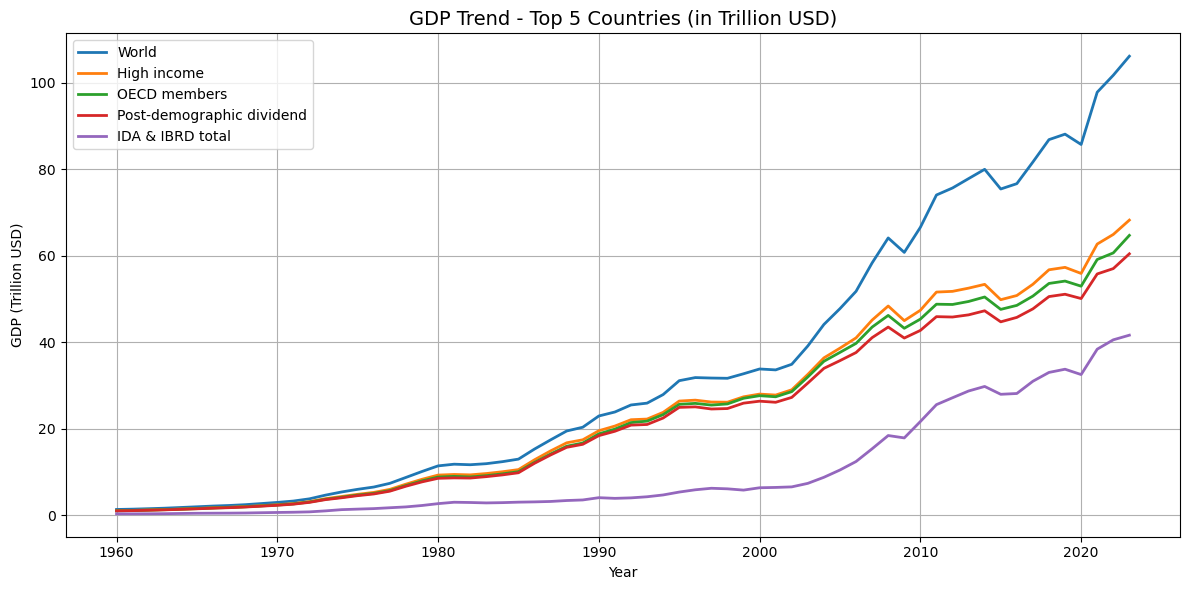

In [11]:
#Get top 5 countries by latest year GDP
latest = gdp_df[gdp_df['Year'] == gdp_df['Year'].max()]
top5 = latest.nlargest(5, 'GDP')['Country Name'].tolist()

plt.figure(figsize=(12, 6))
for country in top5:
    data = gdp_df[gdp_df['Country Name'] == country]
    plt.plot(data['Year'], data['GDP'] / 1e12, label=country, linewidth=2)

plt.title('GDP Trend - Top 5 Countries (in Trillion USD)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP (Trillion USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\ky197\AppData\Local\Temp\ipykernel_19120\2444594165.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='GDP', y='Country Name', palette='Blues_r')


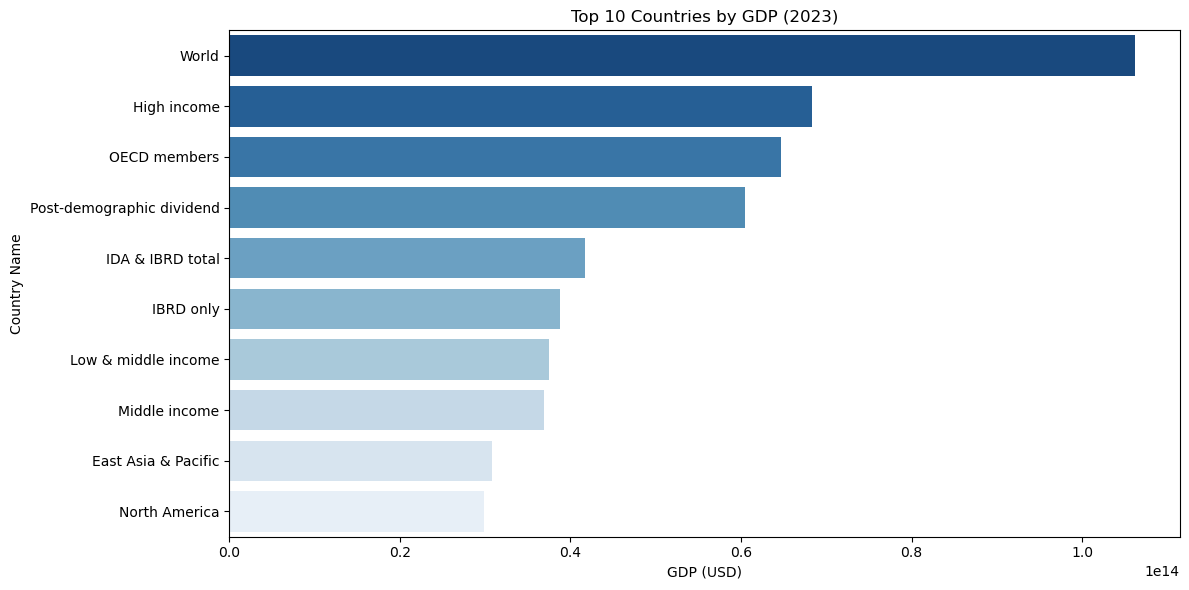

In [12]:
latest_year = gdp_df['Year'].max()
top10 = gdp_df[gdp_df['Year'] == latest_year].nlargest(10, 'GDP')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='GDP', y='Country Name', palette='Blues_r')
plt.title(f'Top 10 Countries by GDP ({latest_year})')
plt.xlabel('GDP (USD)')
plt.tight_layout()
plt.show()

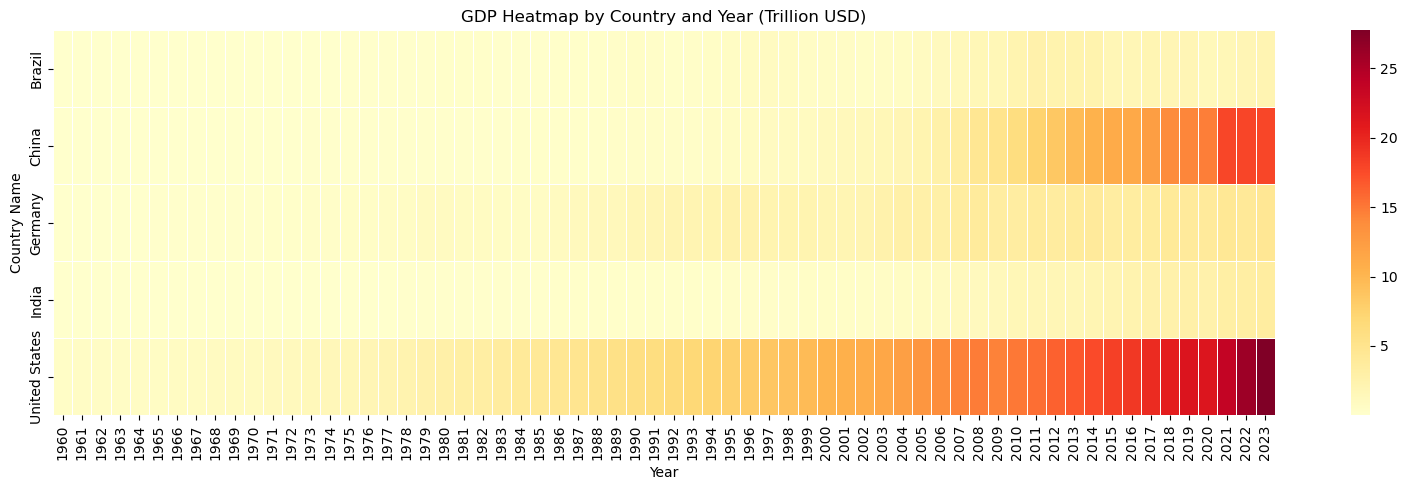

In [13]:
#Filter a few key countries/regions
regions = ['United States', 'China', 'India', 'Germany', 'Brazil']
pivot = gdp_df[gdp_df['Country Name'].isin(regions)].pivot_table(
    index='Country Name', columns='Year', values='GDP'
)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot / 1e12, cmap='YlOrRd', linewidths=0.5)
plt.title('GDP Heatmap by Country and Year (Trillion USD)')
plt.tight_layout()
plt.show()

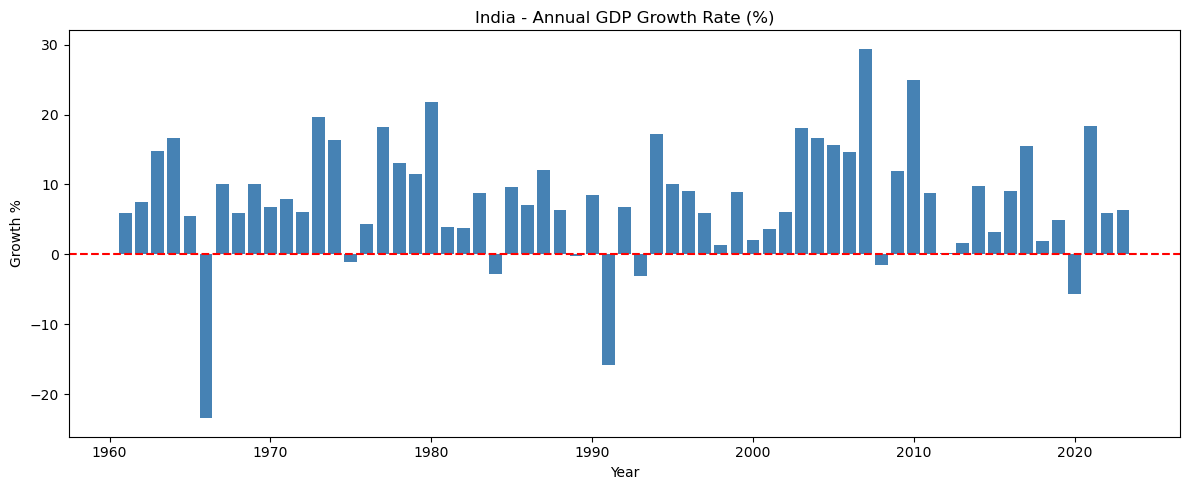

In [14]:
country = 'India'   # change to any country
india = gdp_df[gdp_df['Country Name'] == country].sort_values('Year')
india['Growth %'] = india['GDP'].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.bar(india['Year'], india['Growth %'], color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title(f'{country} - Annual GDP Growth Rate (%)')
plt.xlabel('Year')
plt.ylabel('Growth %')
plt.tight_layout()
plt.show()

In [15]:
gdp_df.to_csv('gdp_cleaned.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


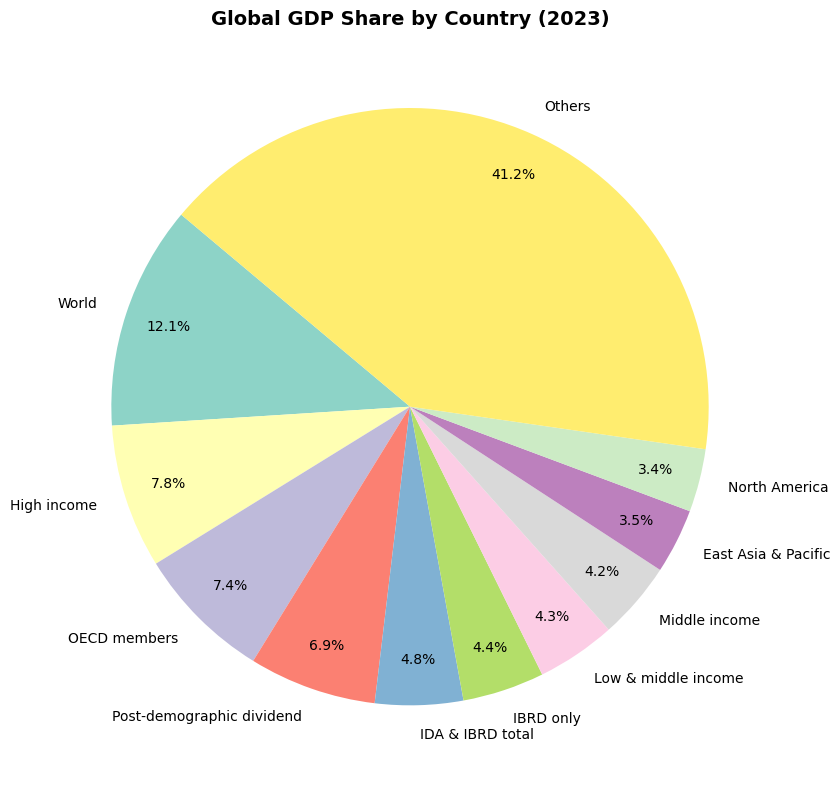

In [16]:
latest_year = gdp_df['Year'].max()

# Get top 10 countries for latest year
top10_pie = gdp_df[gdp_df['Year'] == latest_year].nlargest(10, 'GDP')

# Group the rest as "Others"
total_gdp = gdp_df[gdp_df['Year'] == latest_year]['GDP'].sum()
others_gdp = total_gdp - top10_pie['GDP'].sum()
others_row = pd.DataFrame([{'Country Name': 'Others', 'GDP': others_gdp}])
pie_data = pd.concat([top10_pie[['Country Name', 'GDP']], others_row], ignore_index=True)

plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = plt.pie(
    pie_data['GDP'],
    labels=pie_data['Country Name'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.85
)
plt.title(f'Global GDP Share by Country ({latest_year})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

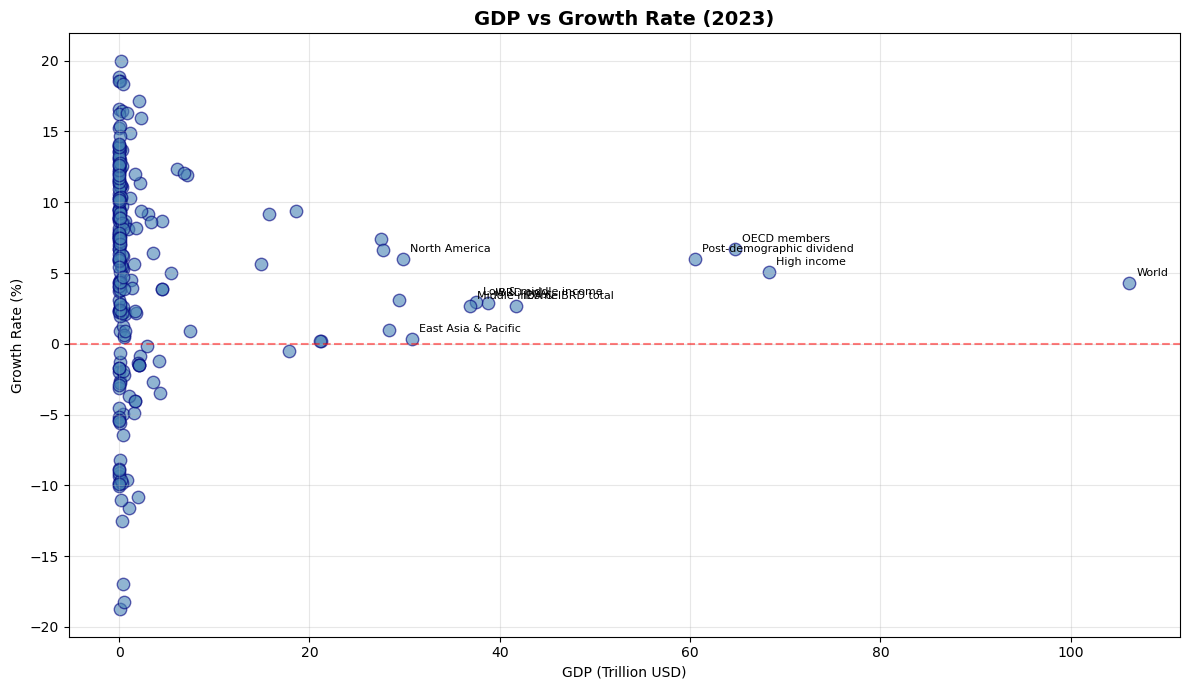

In [17]:
#Calculate growth rate for latest 2 years
year_now = gdp_df['Year'].max()
year_prev = year_now - 1

gdp_now = gdp_df[gdp_df['Year'] == year_now][['Country Name', 'GDP']].rename(columns={'GDP': 'GDP_now'})
gdp_prev = gdp_df[gdp_df['Year'] == year_prev][['Country Name', 'GDP']].rename(columns={'GDP': 'GDP_prev'})

scatter_df = gdp_now.merge(gdp_prev, on='Country Name')
scatter_df['Growth %'] = ((scatter_df['GDP_now'] - scatter_df['GDP_prev']) / scatter_df['GDP_prev']) * 100
scatter_df = scatter_df.dropna()
scatter_df = scatter_df[scatter_df['Growth %'].between(-20, 20)]  # remove extreme outliers

plt.figure(figsize=(12, 7))
plt.scatter(
    scatter_df['GDP_now'] / 1e12,
    scatter_df['Growth %'],
    alpha=0.6,
    color='steelblue',
    edgecolors='navy',
    s=80
)

# Label top 10 by GDP
for _, row in scatter_df.nlargest(10, 'GDP_now').iterrows():
    plt.annotate(row['Country Name'], (row['GDP_now']/1e12, row['Growth %']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title(f'GDP vs Growth Rate ({year_now})', fontsize=14, fontweight='bold')
plt.xlabel('GDP (Trillion USD)')
plt.ylabel('Growth Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

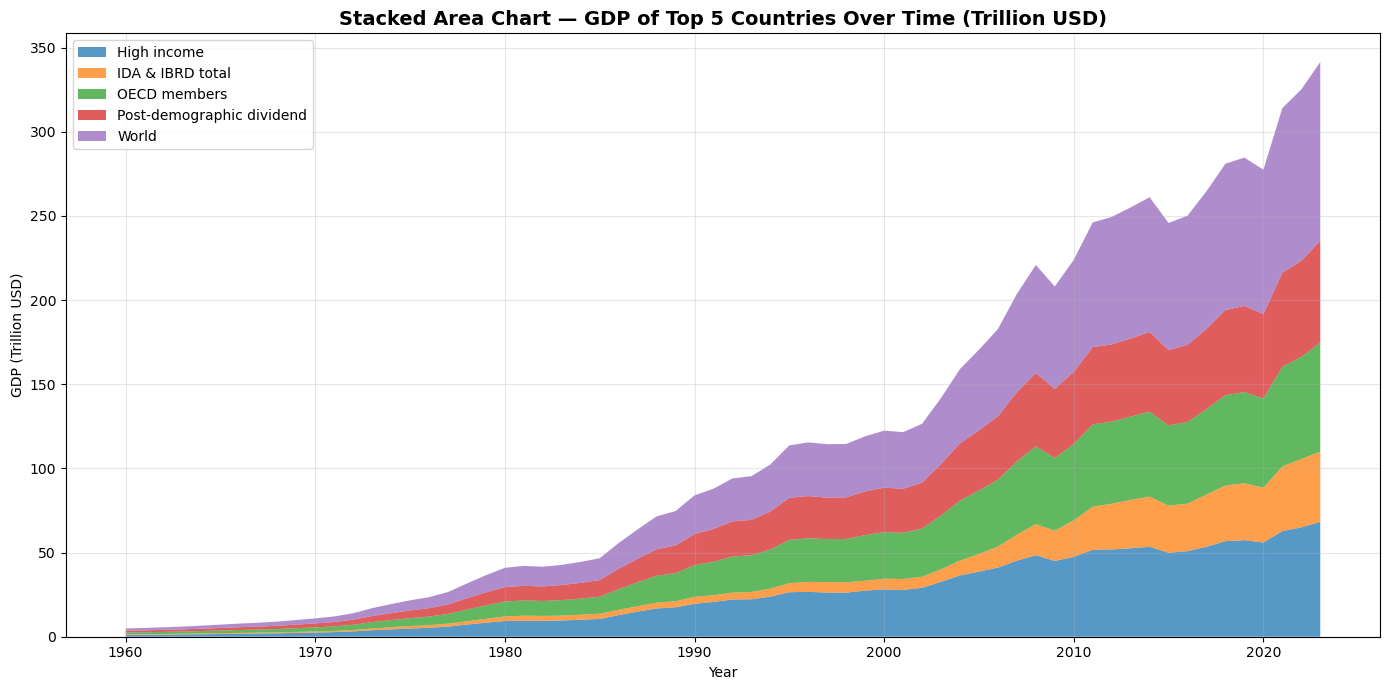

In [18]:
top5_countries = gdp_df[gdp_df['Year'] == gdp_df['Year'].max()].nlargest(5, 'GDP')['Country Name'].tolist()
area_df = gdp_df[gdp_df['Country Name'].isin(top5_countries)]
area_pivot = area_df.pivot_table(index='Year', columns='Country Name', values='GDP') / 1e12

plt.figure(figsize=(14, 7))
plt.stackplot(
    area_pivot.index,
    [area_pivot[c] for c in area_pivot.columns],
    labels=area_pivot.columns,
    alpha=0.75,
    colors=sns.color_palette('tab10', len(top5_countries))
)
plt.title('Stacked Area Chart — GDP of Top 5 Countries Over Time (Trillion USD)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP (Trillion USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

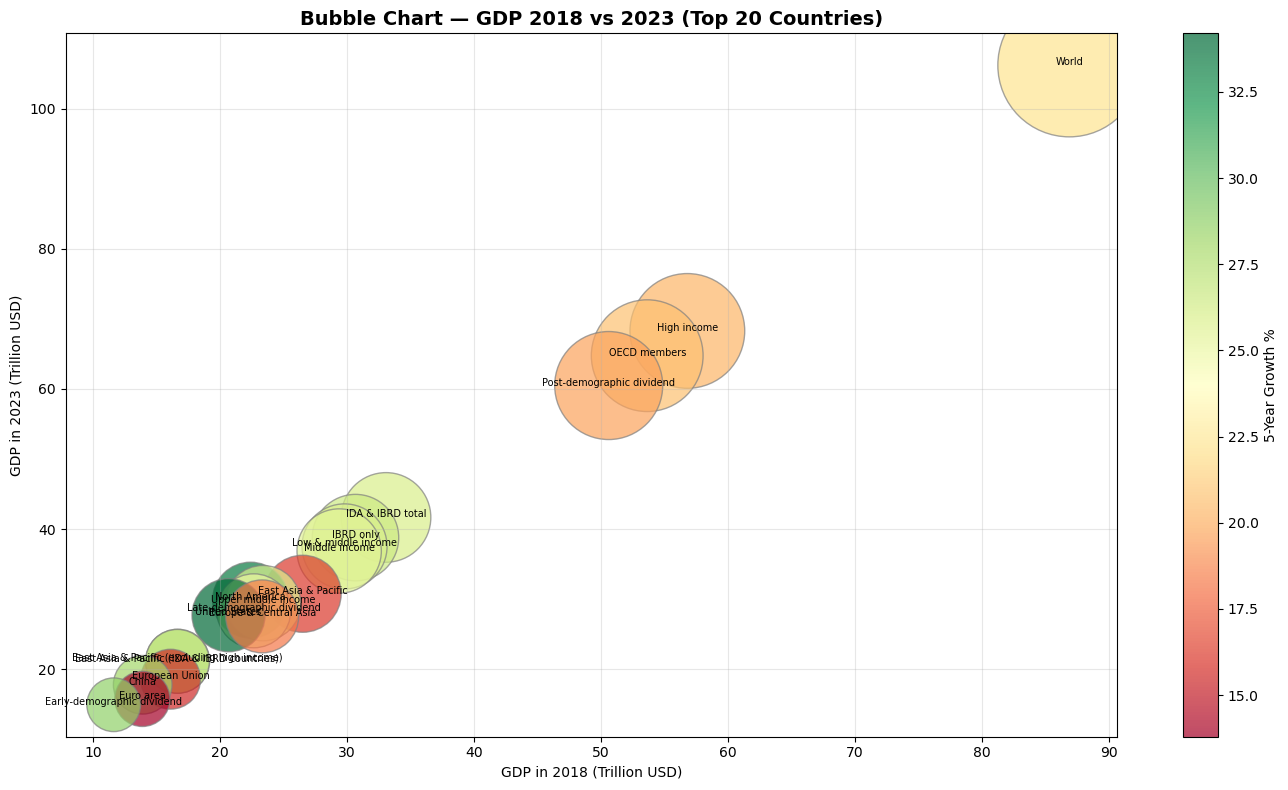

In [19]:
latest_year = gdp_df['Year'].max()
prev_year = latest_year - 5  # compare with 5 years ago

gdp_latest = gdp_df[gdp_df['Year'] == latest_year][['Country Name', 'GDP']].rename(columns={'GDP': 'GDP_latest'})
gdp_prev5 = gdp_df[gdp_df['Year'] == prev_year][['Country Name', 'GDP']].rename(columns={'GDP': 'GDP_prev5'})

bubble_df = gdp_latest.merge(gdp_prev5, on='Country Name').dropna()
bubble_df['Growth_5yr'] = ((bubble_df['GDP_latest'] - bubble_df['GDP_prev5']) / bubble_df['GDP_prev5']) * 100
bubble_df = bubble_df.nlargest(20, 'GDP_latest')  # top 20 countries

plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    bubble_df['GDP_prev5'] / 1e12,
    bubble_df['GDP_latest'] / 1e12,
    s=bubble_df['GDP_latest'] / 1e10,   # bubble size = GDP size
    c=bubble_df['Growth_5yr'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='gray'
)

for _, row in bubble_df.iterrows():
    plt.annotate(row['Country Name'],
                 (row['GDP_prev5']/1e12, row['GDP_latest']/1e12),
                 fontsize=7, ha='center')

plt.colorbar(scatter, label='5-Year Growth %')
plt.title(f'Bubble Chart — GDP {prev_year} vs {latest_year} (Top 20 Countries)', fontsize=14, fontweight='bold')
plt.xlabel(f'GDP in {prev_year} (Trillion USD)')
plt.ylabel(f'GDP in {latest_year} (Trillion USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\ky197\AppData\Local\Temp\ipykernel_19120\3506742867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


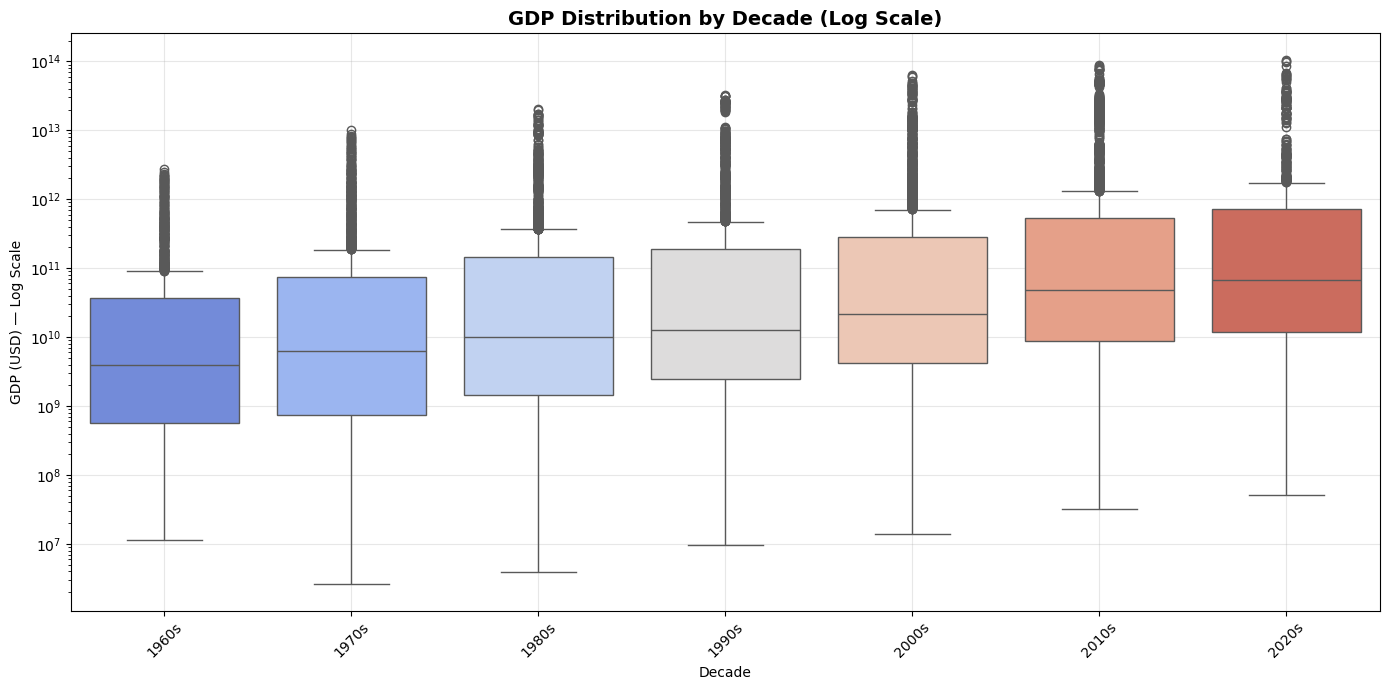

In [20]:
gdp_df['Decade'] = (gdp_df['Year'] // 10) * 10
gdp_df['Decade'] = gdp_df['Decade'].astype(str) + 's'

# Remove nulls and filter to reasonable range
box_df = gdp_df.dropna(subset=['GDP'])
box_df = box_df[box_df['GDP'] > 0]

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=box_df,
    x='Decade',
    y='GDP',
    palette='coolwarm'
)
plt.yscale('log')  # log scale because GDP values vary hugely
plt.title('GDP Distribution by Decade (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('GDP (USD) — Log Scale')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
import plotly.express as px

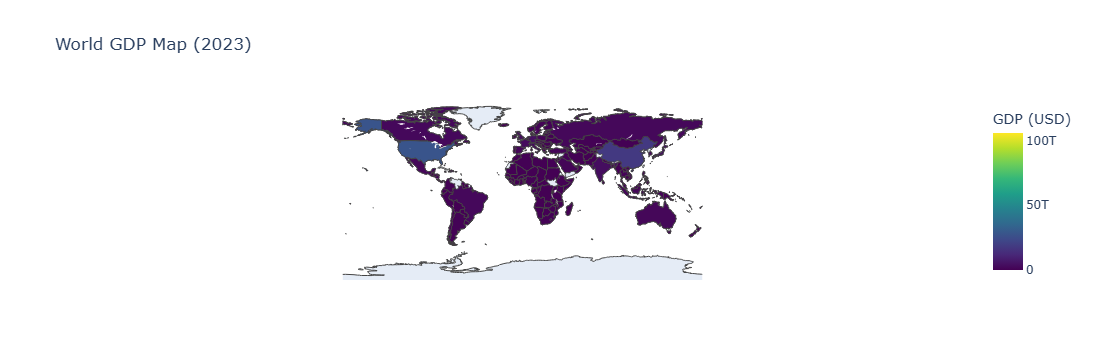

In [22]:
latest_year = gdp_df['Year'].max()
map_df = gdp_df[gdp_df['Year'] == latest_year].dropna(subset=['GDP'])

fig = px.choropleth(
    map_df,
    locations='Country Code',
    color='GDP',
    hover_name='Country Name',
    color_continuous_scale='Viridis',
    title=f'World GDP Map ({latest_year})',
    labels={'GDP': 'GDP (USD)'}
)
fig.update_layout(
    coloraxis_colorbar=dict(title='GDP (USD)'),
    geo=dict(showframe=False, showcoastlines=True)
)
fig.show()

In [23]:
gdp_df.to_csv('gdp_cleaned.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
